In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## import Libraries

In [7]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

## Load local CSV

In [8]:
# Load Dataset

df = pd.read_csv("/kaggle/input/students-performance-dataset/Student_performance_data _.csv")

# Display first 5 rows
df.head(5)

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


## Data type of columns

In [9]:
# viewing the data types of columns
df.dtypes

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

### Check missing values

In [26]:
print(df.isna().sum())

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


## Check duplicate rows

In [28]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

## No. of rows and columns

In [11]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (2392, 15) 

number of rows:  2392
number of columns:  15


## Descriptive summary Statistics

In [12]:
# Statistical summary
df.describe(include='all')

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


## Univariate Analysis

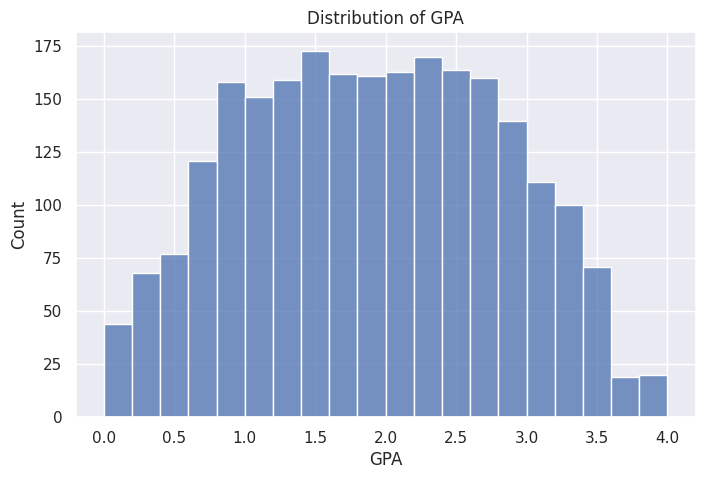

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['GPA'], bins=20)
plt.title("Distribution of GPA")
plt.show()

In [15]:
df.columns

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')

## Distribution of GPA

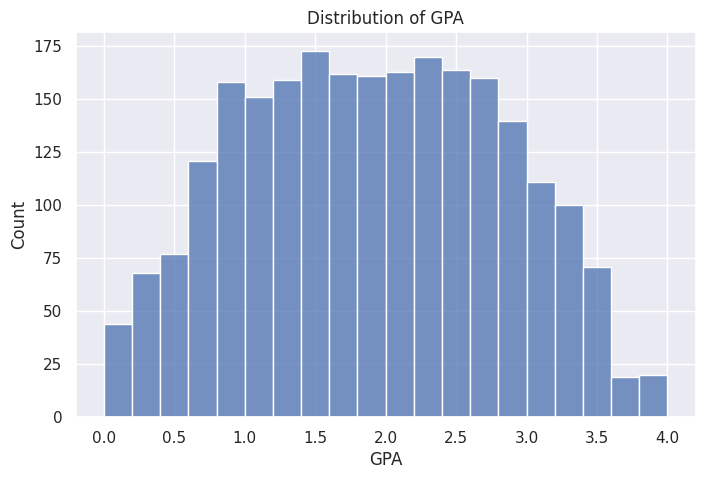

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['GPA'], bins=20)
plt.title("Distribution of GPA")
plt.show()

## Bivariate Analysis

### GPA vs Study Time

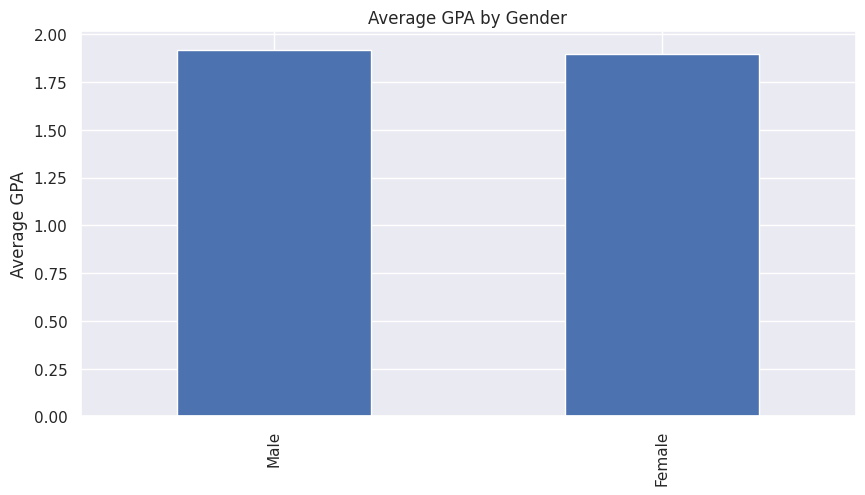

In [19]:
gpa_gender = df.groupby('Gender')['GPA'].mean()

gpa_gender.index = ['Male','Female']  # إذا 0=Male و 1=Female

plt.figure(figsize=(10,5))
gpa_gender.plot(kind='bar')
plt.title("Average GPA by Gender")
plt.ylabel("Average GPA")
plt.show()

### GPA by Extracurricular Activities

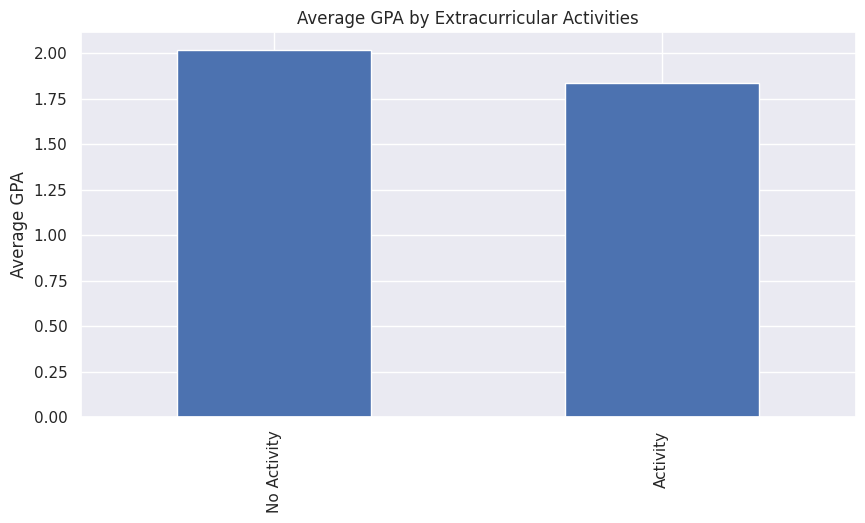

In [21]:
gpa_activity.index = ['No Activity','Activity']

plt.figure(figsize=(10,5))
gpa_activity.plot(kind='bar')
plt.title("Average GPA by Extracurricular Activities")
plt.ylabel("Average GPA")
plt.show()

### GPA by Parental Support

In [22]:
top_parent = df.groupby('ParentalSupport')['GPA'].mean().sort_values(ascending=False)

top_parent.head(10)

ParentalSupport
4    2.191545
3    2.042409
2    1.884246
1    1.755700
0    1.540128
Name: GPA, dtype: float64

### Absences vs GPA Relationship

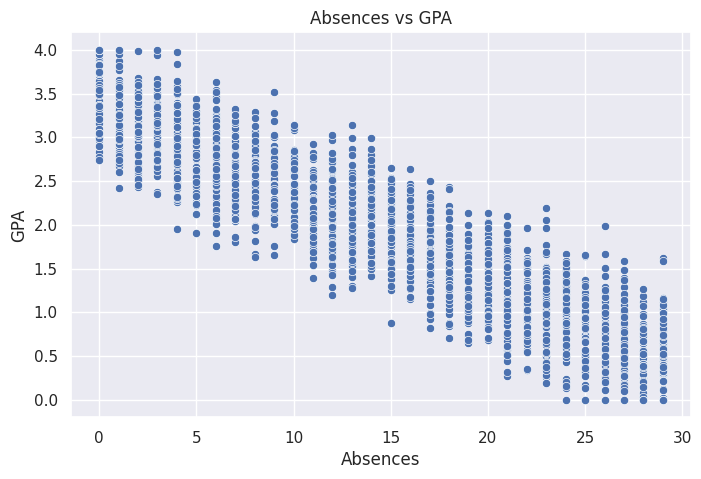

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Absences', y='GPA', data=df)
plt.title("Absences vs GPA")
plt.show()

## Correlation Matrix of Academic Factors

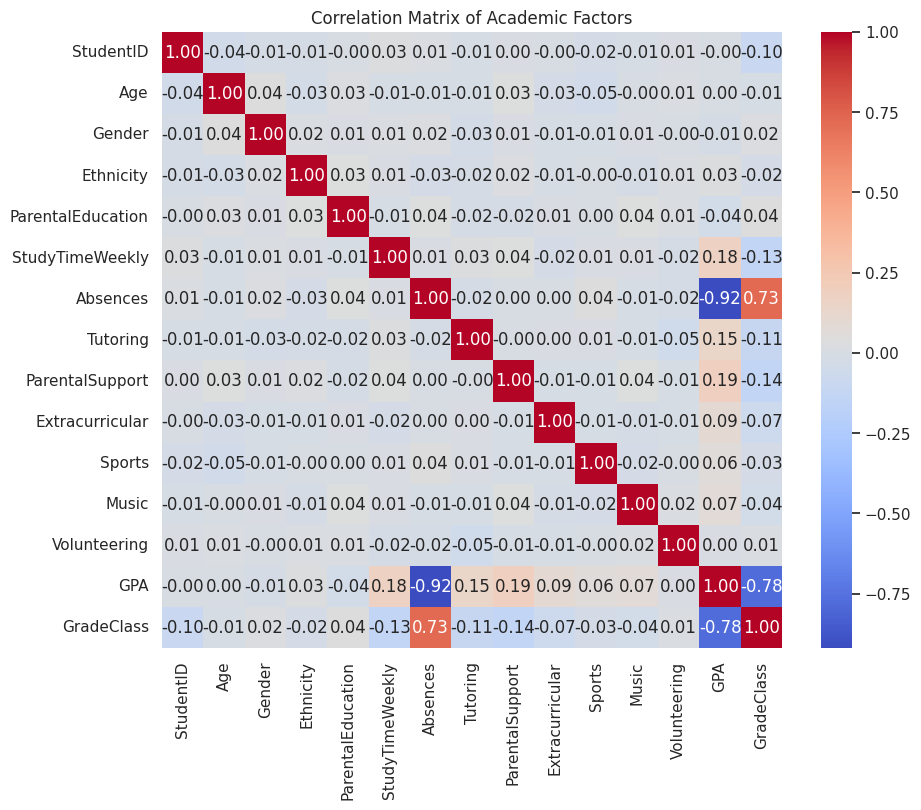

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt


corr_matrix = df.corr()


plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Academic Factors")
plt.show()

## Academic Performance Analysis
### GPA Trend by Study Time

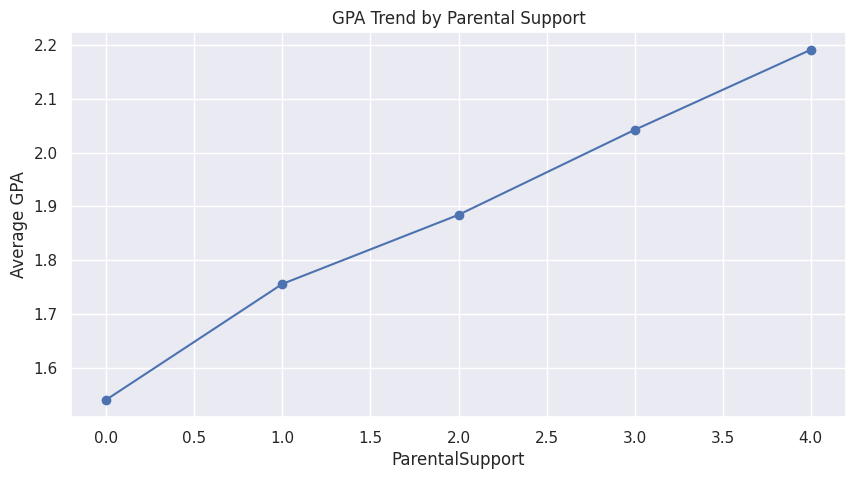

In [25]:
parent_trend = df.groupby('ParentalSupport')['GPA'].mean()

plt.figure(figsize=(10,5))
parent_trend.plot(marker='o')
plt.title("GPA Trend by Parental Support")
plt.ylabel("Average GPA")
plt.show()